In [1]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('../GP_regr')
import plot_settings
import importlib
#import multi_exp_log
import SR_lib

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [2]:
RUN_ID = 'test'
SAVE  = True
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(2e1)

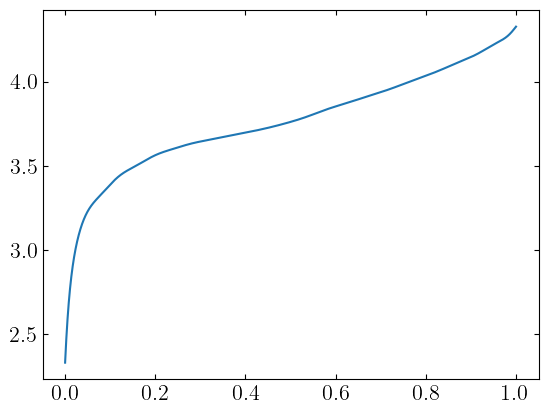

In [3]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)




In [4]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id Ueq_test...
Settings: iterations=20, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.09615142
Equation: 3.7618744

Model 1: Complexity=3, Loss=0.010166902
Equation: soc + 3.2618585

Model 2: Complexity=4, Loss=0.009426608
Equation: 3.095429 + sqrt(soc)

Model 3: Complexity=6, Loss=0.005069186
Equation: (sqrt(soc) * 1.2888154) + 2.9042573

Model 4: Complexity=7, Loss=0.004057675
Equation: (sqrt(sqrt(soc)) + 1.2413484) * 1.8427489

Model 5: Complexity=9, Loss=0.00405272
Equation: (sqrt(sqrt(soc * 1.4879978)) + 1.3555647) * 1.6804768

Model 6: Complexity=10, Loss=0.0035337815
Equation: (sqrt(sqrt(soc * exp(soc))) + 2.0875475) * 1.2509329

Model 7: Complexity=11, Loss=0.003124351
Equation: (sqrt(sqrt(soc * exp(square(soc)))) + 2.067306) * 1.2755128

Model 8: Complexity=12, Loss=0.0023869372
Equation: (sqrt(sqrt(soc / cos(soc))) + 1.659283) * 1.5022709

Model 9: Complexity=16, Loss=0.0008950844
Equation: (sqrt(sqrt(exp(soc) * tan(soc))) + 0.65988284) * (3.0300338 - sqrt(soc))

Model 10: Complexity=18, Loss=0.0007189965
Equation: (sqrt(sqrt(tan(

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (2.7483943 - sin(sqrt(soc) - 0.62083316))*((soc*exp(soc**3))**(1/4) + 0.5477006)
Loss: 0.0003900398
Best model complexity: 19


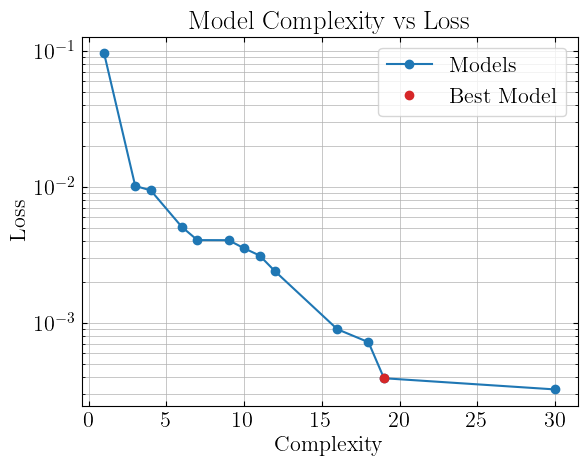

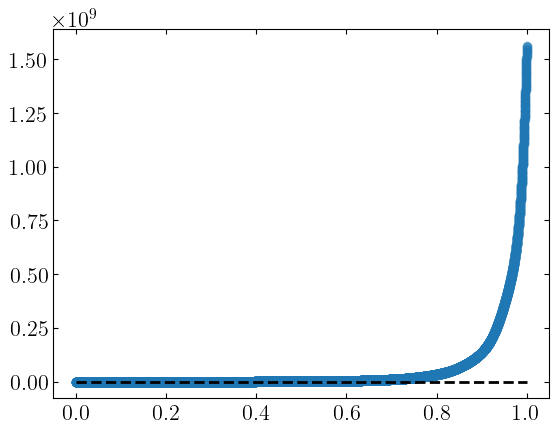

In [5]:
import_reload()
model_Ue = SR_lib.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ueq_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
SR_lib.print_models(df_model_Ue)
SR_lib.print_best_model(model_Ue)
SR_lib.pareto_plot(model_Ue)
SR_lib.parity_plot_Ue(model_Ue, X_train, Y_train, colors=colors, data_set='train')

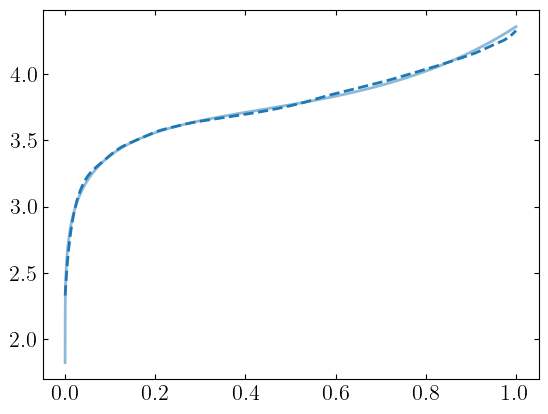

In [6]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [8]:
if SAVE:
    SR_lib.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}', run_id = RUN_ID)
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')